<h3 style='color:#0891B2' align='center'>How to use data augmentation to solve the overfitting issue in CNN</h2>

In this notebook we will build a CNN to classify flower images. 

We will also see how our model overfits and how overfitting can be addressed using data augmentation.

Data augmentation is a process of generating new training samples from current training dataset using transformations such as zoom, rotations, change in contrast etc

Credits: 
we have used tensorflow offical tutorial: https://www.tensorflow.org/tutorials/images/classification as a reference and made bunch of changes to make it simpler

In below image, 4 new training samples are generated from original sample using different transformations

<img src="daisy2.JPG" />

<h4 style='color:#0891B2' align='left'>Import all of the libraries</h4>

In [79]:

import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import pathlib
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

<h4 style='color:#0891B2' align='left'>Download the flowers dataset</h4>

In [82]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
                                    'flower_photos',
                                    origin=dataset_url,
                                    cache_dir='.',
                                    untar=True
                                    )

data_dir = pathlib.Path(data_dir) / "flower_photos"

In [83]:
# This is the directory where the dataset is downloaded
print(data_dir)

datasets\flower_photos\flower_photos


In [90]:
# Find all jpg images inside the data_dir folder and display the first 5 image paths
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [91]:
# How many total images are there ?

image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [94]:
# Get the path of first five roses 
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

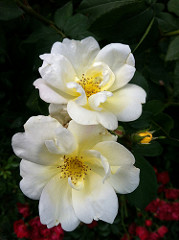

In [110]:
# View the first rose image using the Pillow module
PIL.Image.open(str(roses[0]))

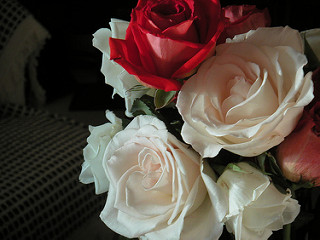

In [111]:
# View the second rose image using the Pillow module
PIL.Image.open(str(roses[1]))


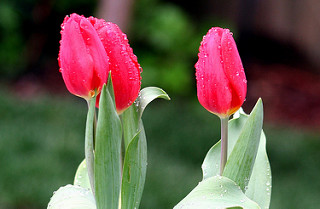

In [112]:
# View the first tulip image using the Pillow module

tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

<h4 style='color:#0891B2' align='left'>Make a dictionary where each flower name is mapped to a list of file paths for all images belonging to that flower class</h4>

In [113]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [114]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

<h4 style='color:#0891B2' align='left'>Make flowers labels dictionary so that a flower is assosciated with a number</h4>

In [116]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [134]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [146]:
# Make a numpy array of first roses image - 
# This is the numerical representation of the image

img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [147]:
img.shape

(240, 179, 3)

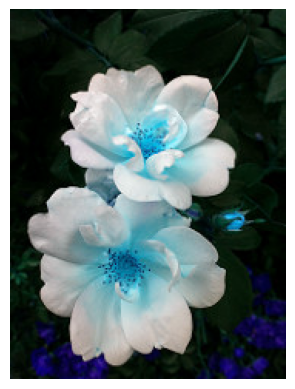

In [148]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')
plt.show()

In [150]:
# How to resize the image using cv2

cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [149]:
# We can see how many images are in each flower folder

for flower_name, images in flowers_images_dict.items():
    print(flower_name)
    print(len(images))


roses
641
daisy
633
dandelion
898
sunflowers
699
tulips
799


In [151]:
# Create two empty lists:
# X will contain the flower image array data
# y will contain the corresponding labels
X, y = [], []


# Go through each flower category and its list of image paths
# Example: flower_name = 'roses'
#          images = [path_to_rose1, path_to_rose2, ...]
for flower_name, images in flowers_images_dict.items():

    # Go through every image belonging to this flower category
    for image in images:

        # Read the image from the file path into a NumPy array
        img = cv2.imread(str(image))

        # Resize every image to the same 180 x 180 dimensions
        # This ensures all images have the same shape for the CNN
        resized_img = cv2.resize(img, (180, 180))

        # Add the processed image (pixel data) to X
        X.append(resized_img)

        # Get the numerical label for this flower and add it to y
        y.append(flowers_labels_dict[flower_name])

In [ ]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [153]:
# Make both lists into numpy arrays

X = np.array(X)
y = np.array(y)

<h4 style='color:#0891B2' align='left'>Train test split now</h4>

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

<h3 style='color:#0891B2'>Preprocessing: Normalise images</h3>

In [58]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

<h3 style='color:#0891B2'>Build convolutional neural network and train it</h3>

In [155]:
# We have 5 different flower categories:
# roses, daisies, dandelions, sunflowers and tulips
num_classes = 5


# Create the CNN model
model = Sequential([
    
    # First convolutional layer
    # 16 filters learn basic features such as edges, lines and simple patterns
    # 3 means a 3x3 convolution filter/kernel
    # padding='same' keeps the image width and height unchanged
    # ReLU introduces non-linearity into the model
    layers.Conv2D(16, 3, padding='same', activation='relu'),

    # Reduce the spatial dimensions of the image
    # This makes the network faster and helps it focus on important features
    layers.MaxPooling2D(),

    
    # Second convolutional layer
    # Increase the number of filters from 16 to 32
    # The network can now learn more complex patterns from the features
    # detected by the previous layer
    layers.Conv2D(32, 3, padding='same', activation='relu'),

    # Again reduce the spatial dimensions
    layers.MaxPooling2D(),

    
    # Third convolutional layer
    # Increase the number of filters from 32 to 64
    # This allows the network to learn even more complex features
    # such as shapes, textures and parts of flowers
    layers.Conv2D(64, 3, padding='same', activation='relu'),

    # Reduce the spatial dimensions again
    layers.MaxPooling2D(),

    
    # Convert the 3D feature maps into a 1D vector
    # so they can be passed into the fully connected Dense layers
    layers.Flatten(),

    
    # Fully connected layer
    # 128 neurons combine the features learned by the convolutional layers
    # to help determine which flower category the image belongs to
    layers.Dense(128, activation='relu'),

    
    # Output layer
    # One output neuron for each flower class
    # The 5 outputs represent the 5 possible flower classes
    #
    # No softmax is used here because we use
    # SparseCategoricalCrossentropy(from_logits=True) below
    layers.Dense(num_classes)
])


# Configure how the model will learn
model.compile(
    
    # Adam is the optimisation algorithm used to update
    # the model's weights during training
    optimizer='adam',

    # Calculate how far the model's predictions are from the
    # correct numerical labels
    #
    # from_logits=True tells TensorFlow that the final Dense layer
    # produces raw scores (logits), rather than probabilities
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    # Track the percentage of predictions that are correct
    metrics=['accuracy']
)


# Train the CNN
# X_train_scaled = training images
# y_train = correct numerical labels for those images
# epochs=30 means the model will go through the entire training
# dataset 30 times
model.fit(
    X_train_scaled,
    y_train,
    epochs=30
)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.3863 - loss: 1.4248
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5581 - loss: 1.0706
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6268 - loss: 0.9417
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7227 - loss: 0.7368
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8143 - loss: 0.5230
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8783 - loss: 0.3441
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9462 - loss: 0.1709
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9764 - loss: 0.0921
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9887 - loss: 0.0495
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9924 - loss: 0.0393
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9916 - loss: 0.0282
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy:

In [156]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6547 - loss: 2.6572


[2.6571502685546875, 0.6546840667724609]

Here we see that while train accuracy is very high (99%), the test accuracy is significantly low (65.4%) indicating overfitting. Let's make some predictions before we use data augmentation to address overfitting

In [157]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


array([[  0.6192453 ,  33.064743  ,   2.6212025 , -19.676674  ,
          2.8938036 ],
       [  8.0150175 ,   0.8039645 ,  -9.386566  ,  -9.366677  ,
         -1.246462  ],
       [ -2.3316257 ,  11.209005  ,  18.165344  ,  -8.6367035 ,
         -6.0912375 ],
       ...,
       [ -5.2413063 ,  -1.1274941 ,  -7.070009  ,   4.64813   ,
          2.3713646 ],
       [ 14.968986  ,   1.5195165 ,  -2.7640977 ,  -2.3739183 ,
         -7.0806236 ],
       [ -0.42149362, -13.059886  ,  -0.77915287,   2.958595  ,
         -0.8311444 ]], dtype=float32)

In [200]:
flowers_labels_dict

{'roses': 0, 'daisy': 1, 'dandelion': 2, 'sunflowers': 3, 'tulips': 4}

In [201]:
flowers_labels_dict_rev = {
    value: key for key, value in flowers_labels_dict.items()
}

In [204]:
element_to_check = 4

score = tf.nn.softmax(predictions[element_to_check])

predicted_class = np.argmax(score)

print("The predicted class is", predicted_class, "which is", flowers_labels_dict_rev[predicted_class])

original_class = y_test[element_to_check]
print("The original class is", original_class, "which is", flowers_labels_dict_rev[original_class])

The predicted class is 3 which is sunflowers
The original class is 2 which is dandelion


The original class is 2


<h3 style='color:#0891B2'>Try to improve accuracy using data augmentation</h3>

In [180]:
img_height = 180
img_width = 180

In [185]:
# Create a sequence of random image transformations.

data_augmentation = keras.Sequential([
    
    layers.RandomFlip(
        "horizontal",
        input_shape=(img_height, img_width, 3)
    ),                                              # Randomly flip the image horizontally. This is useful because a 
                                                    # flower can appear facing either side in a real image.

    layers.RandomRotation(0.1),             # Randomly rotate the image by up to approximately 10% of a full rotation 
                                            # in either direction. This helps the model recognise flowers even when
                                            # the camera/image is slightly tilted.

    layers.RandomZoom(0.1),
                                # Randomly zoom in or out by approximately 10%. This helps the model
                                # learn that the flower is still the same flower even when it 
                                # occupies a different space of the image.

])

<h3 style='color:#0891B2'>See original image vs augmented image</h3>

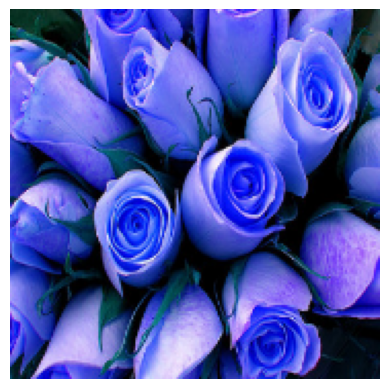

In [217]:
image_to_view = 8
# Original image is below
plt.axis('off')
plt.imshow(X[image_to_view])

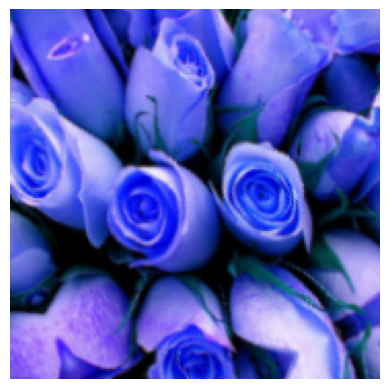

In [218]:
# Augmented Image is below
plt.axis('off')
plt.imshow(data_augmentation(X)[image_to_view].numpy().astype("uint8"))

<h3 style='color:#0891B2'>Train the model using data augmentation and a drop out layer</h3>

In [219]:
# ---------------------------------------------------------
# CNN MODEL
# ---------------------------------------------------------

# We have 5 different flower classes:
# roses, daisy, dandelion, sunflowers and tulips
num_classes = 5


model = Sequential([

    # Apply the random data augmentation before the image
    # enters the CNN.
    #
    # The CNN therefore sees slightly different versions
    # of the training images during training.
    data_augmentation,


    # -----------------------------------------------------
    # CONVOLUTIONAL LAYER 1
    # -----------------------------------------------------

    # 16 filters learn basic visual features such as
    # edges, lines, colours and simple patterns.
    #
    # 3 means a 3x3 convolution kernel.
    # padding='same' keeps the spatial dimensions the same.
    # ReLU adds non-linearity to the network.
    layers.Conv2D(
        16,
        3,
        padding='same',
        activation='relu'
    ),

    # Reduce the width and height of the feature maps.
    # This reduces computation and helps the model focus
    # on the most important features.
    layers.MaxPooling2D(),


    # -----------------------------------------------------
    # CONVOLUTIONAL LAYER 2
    # -----------------------------------------------------

    # Increase the number of filters from 16 to 32.
    # The network can now learn more complex visual patterns.
    layers.Conv2D(
        32,
        3,
        padding='same',
        activation='relu'
    ),

    # Further reduce the spatial dimensions.
    layers.MaxPooling2D(),


    # -----------------------------------------------------
    # CONVOLUTIONAL LAYER 3
    # -----------------------------------------------------

    # Increase the number of filters from 32 to 64.
    # This allows the network to learn more complex features,
    # such as shapes, textures and flower structures.
    layers.Conv2D(
        64,
        3,
        padding='same',
        activation='relu'
    ),

    # Further reduce the spatial dimensions.
    layers.MaxPooling2D(),


    # -----------------------------------------------------
    # DROPOUT
    # -----------------------------------------------------

    # Randomly "turn off" 20% of neurons during training.
    #
    # This prevents the network from relying too heavily
    # on particular neurons and helps reduce overfitting.
    layers.Dropout(0.2),


    # -----------------------------------------------------
    # FLATTEN
    # -----------------------------------------------------

    # Convert the 3D feature maps produced by the
    # convolutional layers into a 1D vector.
    #
    # This allows the features to be passed into the
    # fully connected Dense layers.
    layers.Flatten(),


    # -----------------------------------------------------
    # FULLY CONNECTED LAYER
    # -----------------------------------------------------

    # 128 neurons combine the features learned by the
    # convolutional layers to help classify the flower.
    layers.Dense(
        128,
        activation='relu'
    ),


    # -----------------------------------------------------
    # OUTPUT LAYER
    # -----------------------------------------------------

    # Produce 5 outputs because we have 5 flower classes.
    #
    # These are raw scores (logits), not probabilities.
    # Softmax is therefore not included here because
    # from_logits=True is used in the loss function below.
    layers.Dense(num_classes)
])


# ---------------------------------------------------------
# COMPILE THE MODEL
# ---------------------------------------------------------

model.compile(
    
    # Adam adjusts the model's weights during training
    # to minimise the loss.
    optimizer='adam',

    # Compare the model's predictions with the correct
    # numerical flower labels.
    #
    # SparseCategoricalCrossentropy is appropriate because
    # your labels are integers such as 0, 1, 2, 3 and 4.
    #
    # from_logits=True because the final Dense layer
    # produces raw scores rather than softmax probabilities.
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    # Track how many predictions are correct.
    metrics=['accuracy']
)


# ---------------------------------------------------------
# TRAIN THE MODEL
# ---------------------------------------------------------

# X_train_scaled = training images
# y_train        = corresponding numerical labels
#
# epochs=30 means the model goes through the complete
# training dataset 30 times.
model.fit(
    X_train_scaled,
    y_train,
    epochs=30
)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.4164 - loss: 1.3634
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.5701 - loss: 1.0652
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.6406 - loss: 0.9258
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.6679 - loss: 0.8728
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.6871 - loss: 0.8089
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.7075 - loss: 0.7646
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.7235 - loss: 0.7201
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.7384 - loss: 0.6954
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.7475 - loss: 0.6581
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.7605 - loss: 0.6374
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.7540 - loss: 0.6429
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy:

In [220]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7364 - loss: 0.8861


[0.8860786557197571, 0.7363834381103516]

**You can see that by using data augmentation and drop out layer the accuracy of test set predictions is increased to 73.6%**

In [221]:
predictions_v2 = model.predict(X_test_scaled)
predictions_v2

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


array([[ -7.4851565 ,  13.170064  ,  -1.1902877 ,  -7.7891903 ,
         -3.616944  ],
       [  2.428873  ,   0.3170088 ,  -4.0328717 ,  -5.8265705 ,
          1.15201   ],
       [ -6.0782213 ,  -4.2730265 ,  11.295008  , -13.340584  ,
         -5.569824  ],
       ...,
       [  1.4154207 ,  -8.61702   ,   1.1868881 ,   8.533482  ,
         -1.9679115 ],
       [  4.236099  ,  -3.307623  ,  -0.7781528 ,  -5.8306723 ,
         -0.0336251 ],
       [  1.4351286 ,  -9.502213  ,   0.63838255,   3.0584013 ,
         -2.5721972 ]], dtype=float32)

<h3 style='color:#0891B2'>Time to find out if the wrong prediction got fixed ?</h3>

In [222]:
element_to_check = 4

score = tf.nn.softmax(predictions_v2[element_to_check])

predicted_class = np.argmax(score)

print("The predicted class is", predicted_class, "which is", flowers_labels_dict_rev[predicted_class])

original_class = y_test[element_to_check]
print("The original class is", original_class, "which is", flowers_labels_dict_rev[original_class])

The predicted class is 2 which is dandelion
The original class is 2 which is dandelion
